# Lab 12 — Motion-Model Bayes Localization

Step through a simulated drive while a 2D Bayes filter (gyro-conditioned) tracks the robot.

**Pipeline per BLE round-trip:**

1. Controller picks `(speed_pwm, target_heading)` for the current waypoint.
2. `SimRobot.update(...)` advances physics by one BLE rtt and returns the latest cached ToF samples (each tagged with the yaw at sample time).
3. `Localization2D.predict(...)` shifts the belief by the commanded displacement and diffuses it anisotropically along the heading.
4. `Localization2D.update(...)` indexes into the per-cell ray cache at each ToF's bearing and multiplies the likelihood into the belief.

## 1. Setup

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # so 'from world import ...' resolves

import time, math
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from world import load_world
from sim_robot import SimRobot
from localization2d import Localization2D
from controller import WaypointController, BeliefPlot, step_once
from paths import LAB_PATH_M


In [2]:
PATH = LAB_PATH_M
START_THETA_DEG = 45.0
print('waypoints (m):')
for i, p in enumerate(PATH):
    print(f'  {i}: ({p[0]:+.3f}, {p[1]:+.3f})')


waypoints (m):
  0: (-1.219, -0.914)
  1: (-0.610, -0.305)
  2: (+0.305, -0.305)
  3: (+0.610, -0.914)
  4: (+1.524, -0.914)
  5: (+1.524, -0.610)
  6: (+1.676, -0.305)
  7: (+1.676, +0.610)
  8: (+1.524, +0.914)
  9: (+0.000, +0.914)
  10: (+0.000, +0.000)


## 2. Build the world, sim, localization, controller

In [3]:
map_lines, bounds, loc_params, sim_params, ctl_kwargs = load_world()
print(f'{len(map_lines)} wall segments, bounds={bounds}')
print(f'loc params: {loc_params}')

sim = SimRobot(
    map_lines, sim_params,
    x0=PATH[0][0], y0=PATH[0][1], theta_deg=START_THETA_DEG,
)

t0 = time.time()
loc = Localization2D(map_lines, bounds, params=loc_params)
loc.init_at(PATH[0][0], PATH[0][1], sigma_m=0.10)
print(f'grid={loc.bel.shape}  cell={loc.dx*1000:.1f}x{loc.dy*1000:.1f}mm  '
      f'cache={loc.cache.mean_mm.shape}  build={time.time()-t0:.2f}s')

ctl = WaypointController(path=PATH, **ctl_kwargs)


13 wall segments, bounds=(-1.6764, 1.9812, -1.3716, 1.3716)
loc params: LocParams(n_cells_x=192, n_cells_y=144, n_angles=720, smooth_sigma_deg=8.0, max_dist_m=6.0, sensor_sigma_mm=48.0, tof_sat_mm=2000.0, robust_z_max=5.0, motion_long_sigma_per_m=0.256, motion_long_sigma_per_pwm=0.032, motion_base_sigma_m=0.064, pwm_to_vel_mm_s=20.0, tof_sensor_angles_deg=(0.0, -90.0), flip_std_ratio=0.2)
grid=(192, 144)  cell=19.1x19.0mm  cache=(192, 144, 720)  build=2.29s


## 3. Initial state

The belief starts as a tight Gaussian at the known start pose.

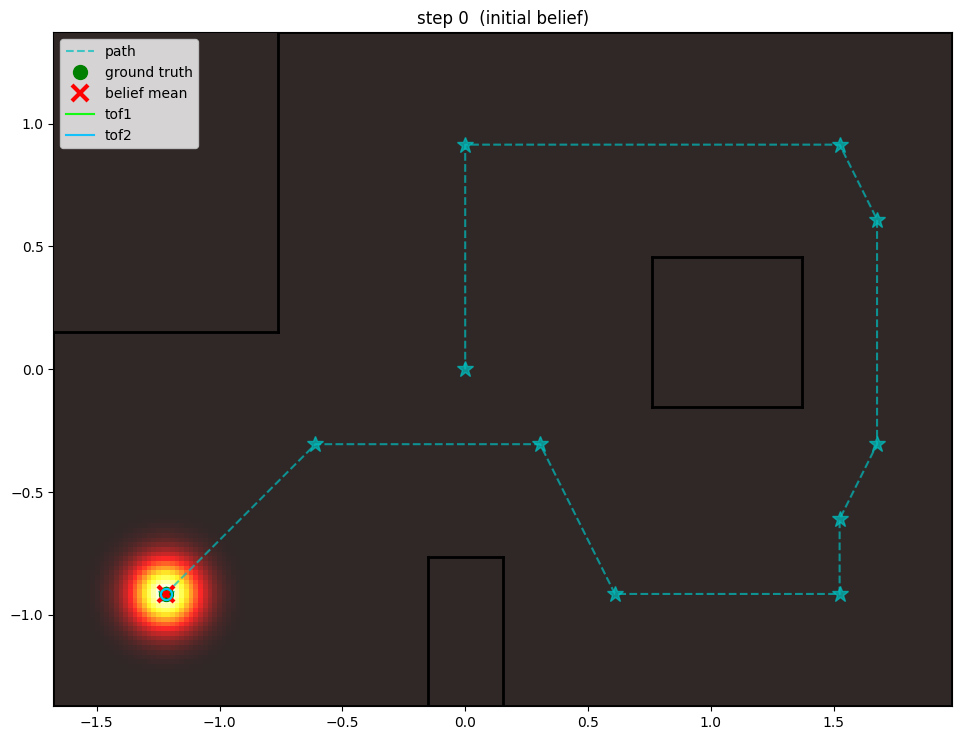

In [4]:
plot = BeliefPlot(loc, map_lines, path=PATH)
gx, gy, _ = sim.pose
# Synthetic empty response just to draw the initial state.
from sim_robot import DriveUpdateResponse
empty = DriveUpdateResponse(0, 0, 0, 0.0, 0, 0, 0.0, 0.0)
plot.update((gx, gy), empty, title='step 0  (initial belief)')
plt.show()


## 4. Step once at a time

Re-run this cell to advance the simulation one BLE round-trip and refresh the plot. Watch the belief shift along the commanded heading and tighten as the side-facing ToF nails the lateral coordinate.

step 1  t=0.10s  wp=1/10  gt=(-1.226,-0.917)  bel=(-1.222,-0.935)  err=19mm  tof1=2390mm@+12.0deg  tof2=440mm@-78.0deg


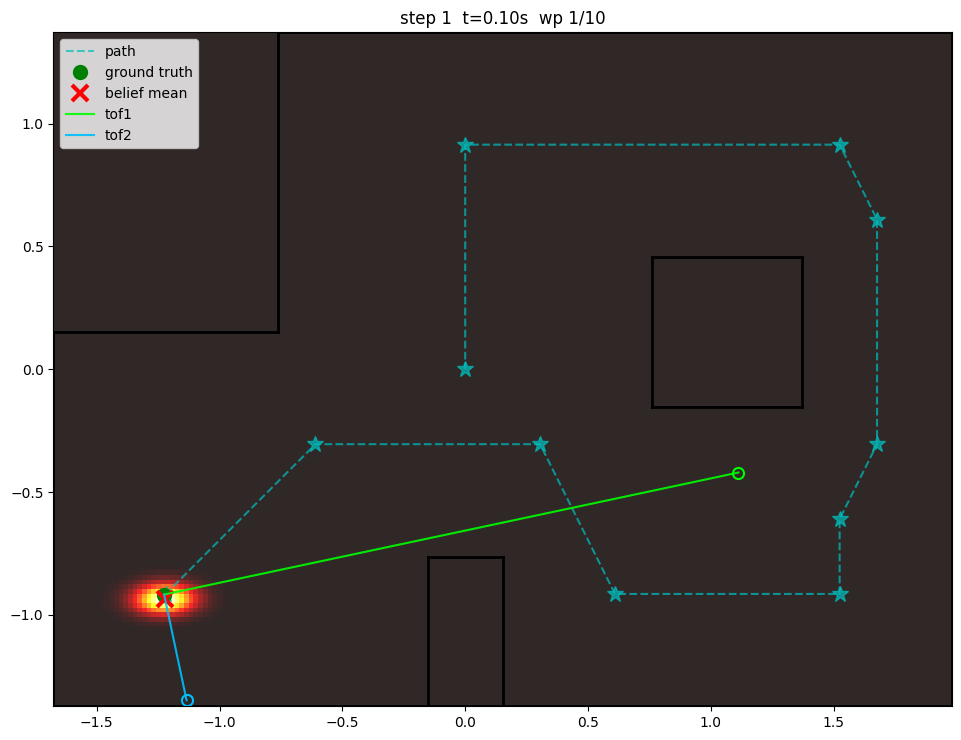

In [5]:
if 'last_t_us' not in dir():
    last_t_us = 0
if 'step' not in dir():
    step = 0
if 'last_yaw' not in dir():
    last_yaw = START_THETA_DEG

resp, last_t_us = await step_once(sim, loc, ctl, last_t_us=last_t_us, last_yaw_deg=last_yaw)
last_yaw = resp.yaw_deg
step += 1

gx, gy, gth = sim.pose
bx, by = loc.mean_xy()
err_mm = math.hypot(bx - gx, by - gy) * 1000
print(
    f'step {step}  t={sim.t_s:.2f}s  wp={ctl.idx}/{len(PATH)-1}  '
    f'gt=({gx:+.3f},{gy:+.3f})  bel=({bx:+.3f},{by:+.3f})  err={err_mm:.0f}mm  '
    f'tof1={resp.tof1_dist_mm}mm@{resp.tof1_yaw_deg:+.1f}deg  '
    f'tof2={resp.tof2_dist_mm}mm@{resp.tof2_yaw_deg:+.1f}deg'
)
plot.update((gx, gy), resp, title=f'step {step}  t={sim.t_s:.2f}s  wp {ctl.idx}/{len(PATH)-1}')
display(plot.fig)


## 5. Run to completion (live redraw)

Plays through the rest of the path, re-rendering every step. Stop with `Kernel → Interrupt`.

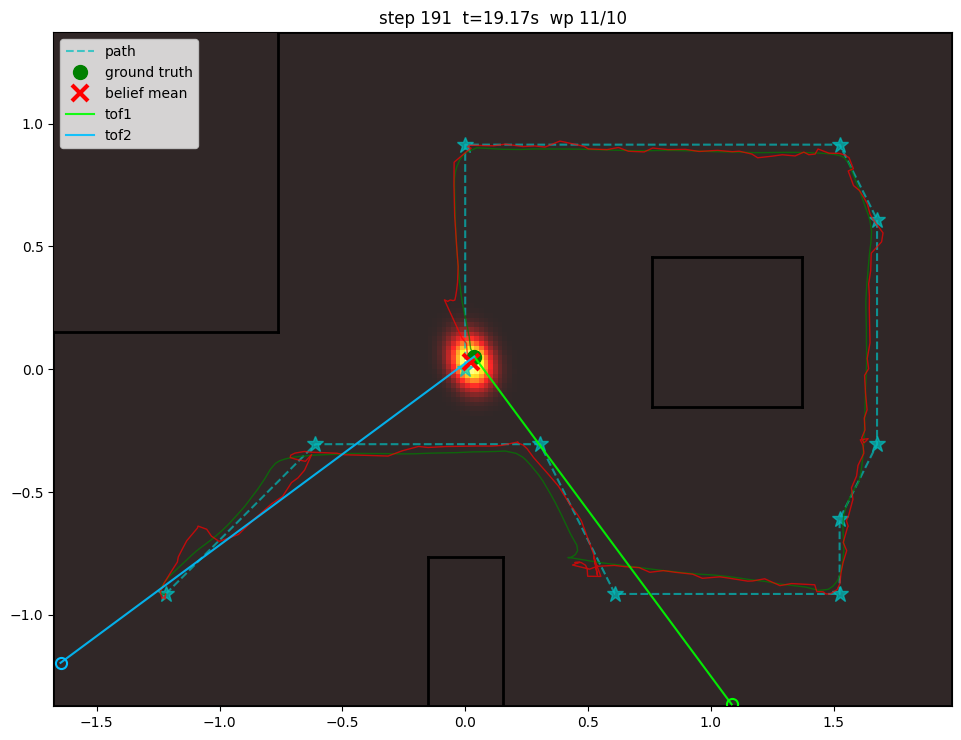

done in 191 steps. final gt=(+0.037,+0.052)  bel=(+0.025,+0.030)  err=24mm


In [6]:
last_yaw = resp.yaw_deg
while not ctl.done:
    resp, last_t_us = await step_once(sim, loc, ctl, last_t_us=last_t_us, last_yaw_deg=last_yaw)
    last_yaw = resp.yaw_deg
    step += 1
    gx, gy, _ = sim.pose
    plot.update((gx, gy), resp,
                title=f'step {step}  t={sim.t_s:.2f}s  wp {ctl.idx}/{len(PATH)-1}')
    clear_output(wait=True)
    display(plot.fig)

bx, by = loc.mean_xy()
err_mm = math.hypot(bx - gx, by - gy) * 1000
print(f'done in {step} steps. final gt=({gx:+.3f},{gy:+.3f})  bel=({bx:+.3f},{by:+.3f})  err={err_mm:.0f}mm')


## 6. Reset and run closed-loop on the belief

Same path, but the controller now sees `loc.argmax_xy()` instead of ground truth. Useful to see how filter error feeds back into control.

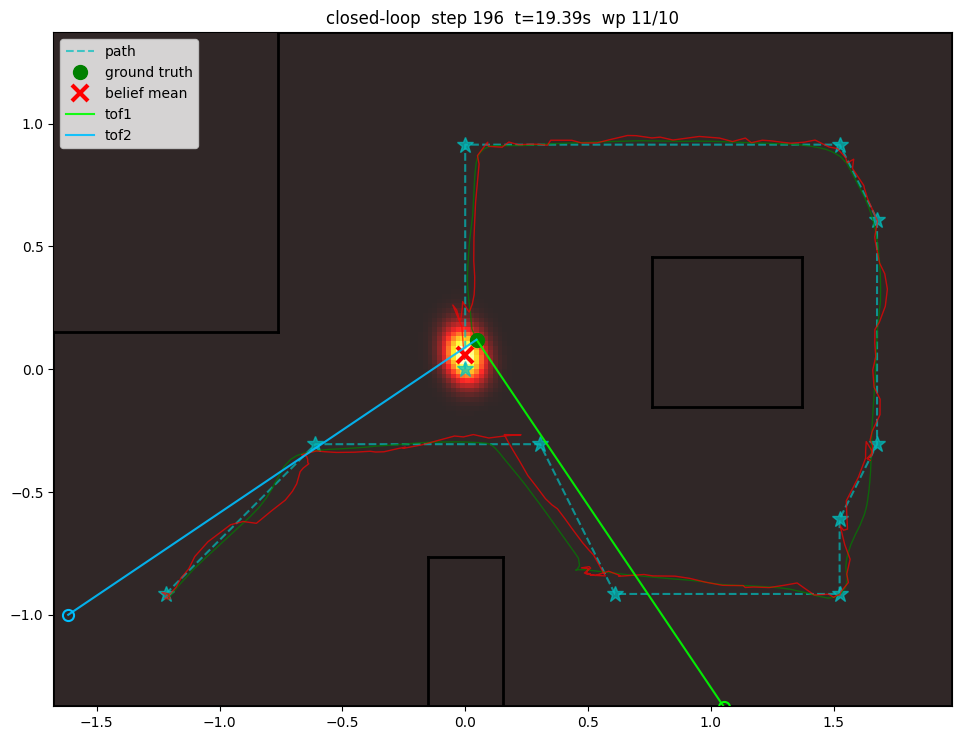

done in 196 steps. final gt=(+0.046,+0.121)  bel=(-0.001,+0.059)  err=78mm


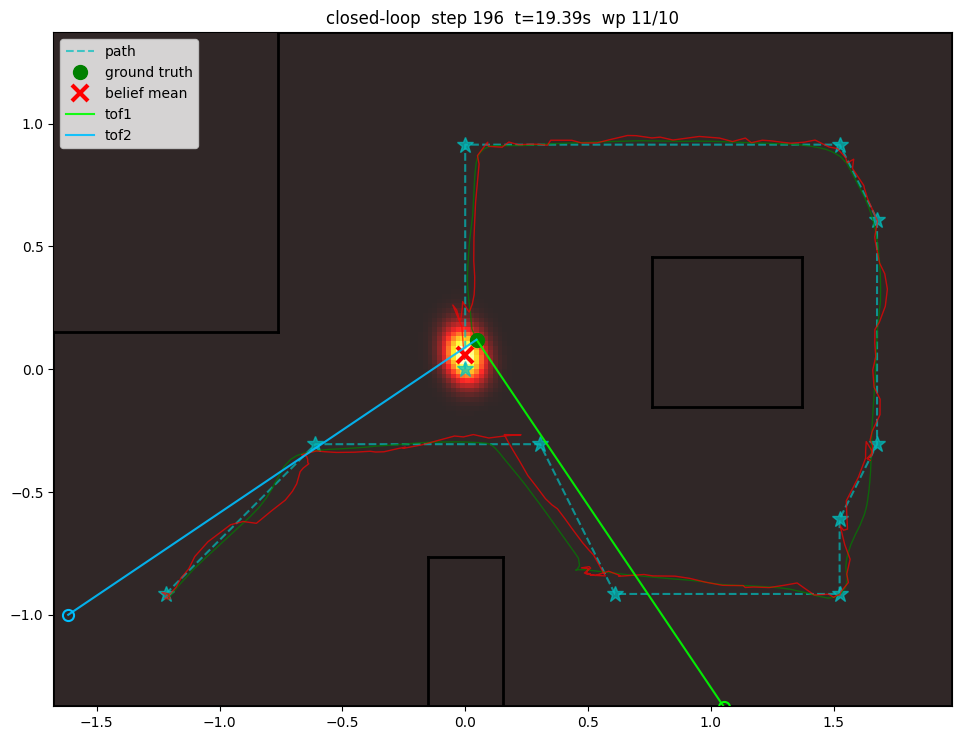

In [7]:
sim = SimRobot(map_lines, sim_params, x0=PATH[0][0], y0=PATH[0][1],
               theta_deg=START_THETA_DEG)
loc.init_at(PATH[0][0], PATH[0][1], sigma_m=0.10)
ctl = WaypointController(path=PATH, **ctl_kwargs)
plot = BeliefPlot(loc, map_lines, path=PATH)

last_t_us, step = 0, 0
last_yaw = START_THETA_DEG
while not ctl.done:
    resp, last_t_us = await step_once(sim, loc, ctl, use_belief=True,
                                      last_t_us=last_t_us, last_yaw_deg=last_yaw)
    last_yaw = resp.yaw_deg
    step += 1
    gx, gy, _ = sim.pose
    plot.update((gx, gy), resp,
                title=f'closed-loop  step {step}  t={sim.t_s:.2f}s  wp {ctl.idx}/{len(PATH)-1}')
    clear_output(wait=True)
    display(plot.fig)

bx, by = loc.mean_xy()
err_mm = math.hypot(bx - gx, by - gy) * 1000
print(f'done in {step} steps. final gt=({gx:+.3f},{gy:+.3f})  bel=({bx:+.3f},{by:+.3f})  err={err_mm:.0f}mm')
